In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from galerkin_arima import GalerkinSARIMA
import time
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)
warnings.filterwarnings('ignore', category=PendingDeprecationWarning)
warnings.filterwarnings('ignore', category=ImportWarning)
warnings.filterwarnings('ignore', category=UnicodeWarning)
warnings.filterwarnings('ignore', category=BytesWarning)
warnings.filterwarnings('ignore', category=ResourceWarning)
warnings.filterwarnings('ignore', category=Warning)

In [2]:
# Generate toy datasets (for testing)
np.random.seed(123)
n = 300
t = np.arange(n)

# A: Noisy ARMA(2,1)
phi_true = [0.6, -0.3]
theta_true = [0.5]
eps = np.random.normal(scale=1.0, size=n)
y_a = np.zeros(n)
for i in range(2, n):
    y_a[i] = (phi_true[0] * y_a[i-1] + phi_true[1] * y_a[i-2] + theta_true[0] * eps[i-1] + eps[i])

# B: Seasonal sine + noise (period m=20)
y_b = np.sin(2 * np.pi * t / 20) + 0.5 * np.random.normal(size=n)

# C: Linear trend + AR(1)
eps_c = np.random.normal(scale=0.5, size=n)
y_c = np.zeros(n)
for i in range(1, n):
    y_c[i] = 0.01 * i + 0.8 * y_c[i-1] + eps_c[i]

# D: Nonlinear (Logistic map) + noise
r = 3.8
eps_d = np.random.normal(scale=0.02, size=n)
y_d = np.zeros(n)
y_d[0] = 0.4
for i in range(1, n):
    y_d[i] = r * y_d[i-1] * (1 - y_d[i-1]) + eps_d[i]

datasets = {
    'Noisy_ARMA': y_a,
    'Seasonal': y_b,
    'Trend_AR': y_c,
    'Nonlinear': y_d
}


In [3]:


window = 30
horizon = 100
num_runs = 1
p_values = [0,1,2]
q_values = [0,1,2]
P_values = [0,1,2]
Q_values = [0,1,2]
m_seasonal = 2

orders = [(p, q, P, Q) for p in p_values for q in q_values for P in P_values for Q in Q_values]


In [4]:


all_results = []
first_run_preds = {}  # Store predictions from first run for plotting
first_run_pis = {}  # Store prediction intervals from first run for plotting
bic_results = []  # Store BIC values for model selection

# Define algorithms to run (GARIMA only)
algorithms = [
    {'name': 'GARIMA-OLS', 'use_ridge': False},
    {'name': 'GARIMA-Ridge', 'use_ridge': True, 'ridge_lambda_ar': 1.5, 'ridge_lambda_ma': 1.0, 
     'ridge_weight_scheme': 'poly', 'ridge_eta': 1.5},
]

for run in range(1, num_runs + 1):
    runs_left = num_runs - run
    print(f"\n=== Run {run}/{num_runs}  (runs left after this: {runs_left}) ===")

    for name, series in datasets.items():
        m = m_seasonal

        for p, q, P, Q in tqdm(orders, desc=f"Param combos for {name}", total=len(orders), leave=False):
            y_true = series[window:window + horizon]
            
            # Run each algorithm
            for alg_config in algorithms:
                alg_name = alg_config['name']
                preds = []
                iter_times = []
                
                combo_start = time.perf_counter()
                
                for i in range(window, window + horizon):
                    t0 = time.perf_counter()
                    train = series[:i]
                    
                    try:
                        # GalerkinSARIMA (OLS or Ridge)
                        model = GalerkinSARIMA(
                            order=(p, 0, q), 
                            seasonal_order=(P, 0, Q, m), 
                            basis_functions=["quadratic", "sigmoid", "linear"],
                            forecast_method="direct",
                            use_ridge=alg_config['use_ridge'],
                            ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 1.0),
                            ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 1.0),
                            ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                            ridge_eta=alg_config.get('ridge_eta', 1.0),
                            standardize=True
                        )
                        model.fit(train)
                        pred = model.forecast(steps=4)
                        preds.append(pred)
                        
                        # Calculate BIC for model selection (only on first run)
                        if run == 1:
                            try:
                                bic_val = model.bic()
                                bic_results.append({
                                    'Dataset': name,
                                    'p': p, 'q': q, 'P': P, 'Q': Q,
                                    'Alg': alg_name,
                                    'BIC': bic_val
                                })
                            except:
                                pass
                        
                        # Get prediction intervals for plotting (only first run, at selected points)
                        if run == 1:
                            # Compute PIs at a few key points: start, middle, end
                            pi_points = [window, window + horizon//2, window + horizon - 1]
                            
                            if i in pi_points:
                                # Minimum training length: need enough for model order + some buffer for bootstrap
                                # Bootstrap needs at least ~20-30 points to work reasonably
                                min_train_len = max(20, max(p, P*m, q, Q*m) + 5)
                                if len(train) >= min_train_len:  # Only compute if enough data
                                    try:
                                        # Model is already fitted, so we can use it directly
                                        # But prediction_intervals will refit, so we need to pass train
                                        # Use smaller bootstrap for speed
                                        pi_result = model.prediction_intervals(
                                            train, steps=1, n_bootstrap=50,  # Reduced for speed
                                            random_state=42, alpha=0.05
                                        )
                                        
                                        key = (name, p, q, P, Q, alg_name)
                                        if key not in first_run_pis:
                                            first_run_pis[key] = {}
                                        
                                        # Store the result directly - prediction_intervals returns tuples
                                        # pi_result should have 'pi' and 'ci_mean' as tuples (lower, upper)
                                        if 'pi' in pi_result and 'ci_mean' in pi_result:
                                            # Ensure they're tuples/lists with 2 elements
                                            pi_val = pi_result['pi']
                                            ci_val = pi_result['ci_mean']
                                            
                                            # Convert to tuple if needed
                                            if isinstance(pi_val, np.ndarray):
                                                pi_val = tuple(pi_val.tolist())
                                            elif isinstance(pi_val, list):
                                                pi_val = tuple(pi_val)
                                            elif not isinstance(pi_val, tuple):
                                                pi_val = (float(pi_val), float(pi_val))
                                            
                                            if isinstance(ci_val, np.ndarray):
                                                ci_val = tuple(ci_val.tolist())
                                            elif isinstance(ci_val, list):
                                                ci_val = tuple(ci_val)
                                            elif not isinstance(ci_val, tuple):
                                                ci_val = (float(ci_val), float(ci_val))
                                            
                                            # Store the intervals
                                            first_run_pis[key][i] = {
                                                'forecast': float(pi_result.get('forecast', 0.0)),
                                                'ci_mean': ci_val,
                                                'pi': pi_val
                                            }
                                            
                                        else:
                                            pass  # PI result missing keys - skip silently
                                    except Exception as e:
                                        # Skip failed PI computations silently
                                        pass
                                else:
                                    pass  # Insufficient training data - skip silently
                            else:
                                pass  # Time point not in pi_points - skip silently
                                
                    except Exception as e:
                        # If fitting fails, append NaNs (silent)
                        preds.append(np.full(4, np.nan))
                    
                    iter_times.append(time.perf_counter() - t0)
                
                combo_sec = time.perf_counter() - combo_start
                
                preds = np.array(preds)
                # Extract only the last step of each multi-step forecast
                last_step_preds = preds[:, -1] if preds.ndim > 1 else preds
                
                # Store predictions from first run for plotting
                if run == 1:
                    first_run_preds[(name, p, q, P, Q, alg_name)] = last_step_preds
                
                # Calculate metrics
                mask = ~np.isnan(last_step_preds)
                mae = mean_absolute_error(y_true[mask], last_step_preds[mask]) if mask.any() else np.nan
                rmse = np.sqrt(mean_squared_error(y_true[mask], last_step_preds[mask])) if mask.any() else np.nan
                
                # Timing stats
                mean_iter_ms = float(np.mean(iter_times)) * 1000 if len(iter_times) else np.nan
                median_iter_ms = float(np.median(iter_times)) * 1000 if len(iter_times) else np.nan
                max_iter_ms = float(np.max(iter_times)) * 1000 if len(iter_times) else np.nan
                throughput_iters_per_sec = (len(iter_times) / combo_sec) if combo_sec > 0 else np.nan
                
                all_results.append([
                    name, p, q, P, Q, run, alg_name,
                    mae, rmse,
                    mean_iter_ms, median_iter_ms, max_iter_ms,
                    combo_sec, len(iter_times), throughput_iters_per_sec
                ])

# Aggregate and print for verification (timing columns included)
df = pd.DataFrame(
    all_results,
    columns=[
        'Dataset', 'p', 'q', 'P', 'Q', 'Run', 'Alg',
        'MAE', 'RMSE',
        'mean_iter_ms', 'median_iter_ms', 'max_iter_ms',
        'combo_sec', 'num_iters', 'throughput_iters_per_sec'
    ]
)
agg = df.groupby(['Dataset', 'p', 'q', 'P', 'Q', 'Alg'], as_index=False).mean()

print("\nAveraged over {} runs (including timing):\n".format(num_runs))
print(agg.to_markdown(index=False))


=== Run 1/1  (runs left after this: 0) ===



Averaged over 1 runs (including timing):

| Dataset    |   p |   q |   P |   Q | Alg          |   Run |       MAE |      RMSE |   mean_iter_ms |   median_iter_ms |   max_iter_ms |   combo_sec |   num_iters |   throughput_iters_per_sec |
|:-----------|----:|----:|----:|----:|:-------------|------:|----------:|----------:|---------------:|-----------------:|--------------:|------------:|------------:|---------------------------:|
| Noisy_ARMA |   0 |   0 |   0 |   0 | GARIMA-OLS   |     1 | 1.35755   | 1.70171   |       0.977705 |         0.698313 |       13.2993 |   0.0977969 |         100 |                   1022.53  |
| Noisy_ARMA |   0 |   0 |   0 |   0 | GARIMA-Ridge |     1 | 1.35755   | 1.70171   |       0.993293 |         0.700854 |       14.5415 |   0.0993447 |         100 |                   1006.6   |
| Noisy_ARMA |   0 |   0 |   0 |   1 | GARIMA-OLS   |     1 | 1.35755   | 1.70171   |       1.65812  |         1.09156  |       29.6373 |   0.16583   |         100 |            


Debug: Plotting Noisy_ARMA (p=1, q=0, P=1, Q=0)
  GARIMA-OLS: Found 3 PI points
    t=30: PI=[-1.992, 3.207], CI=[-1.528, 2.052]
    t=80: PI=[-3.209, 2.925], CI=[-2.265, 1.993]
    t=129: PI=[-2.634, 3.535], CI=[-1.454, 2.174]
Saved: synthetic_comparison_plots/Noisy_ARMA_p1_q0_P1_Q0_m2_with_PI.png


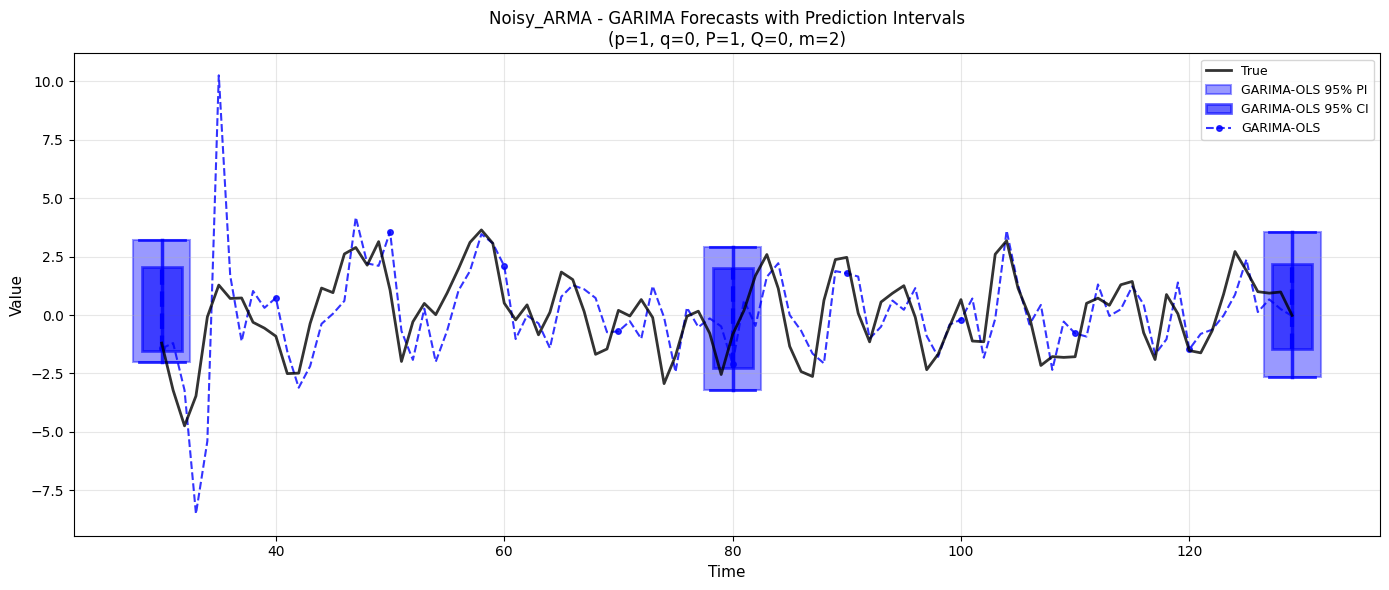


Noisy_ARMA (p=1, q=0, P=1, Q=0):
  GARIMA-OLS      - MAE: 1.2132, RMSE: 1.6999, Time: 0.25s
  GARIMA-Ridge    - MAE: 1.0234, RMSE: 1.2312, Time: 0.31s
  BIC values:
    GARIMA-OLS      - BIC: 1.7601
    GARIMA-OLS      - BIC: 1.7047
    GARIMA-OLS      - BIC: 1.8119
    GARIMA-OLS      - BIC: 2.0418
    GARIMA-OLS      - BIC: 2.0284
    GARIMA-OLS      - BIC: 2.0314
    GARIMA-OLS      - BIC: 1.9704
    GARIMA-OLS      - BIC: 1.9118
    GARIMA-OLS      - BIC: 1.8638
    GARIMA-OLS      - BIC: 1.8134
    GARIMA-OLS      - BIC: 1.7607
    GARIMA-OLS      - BIC: 1.7118
    GARIMA-OLS      - BIC: 1.7109
    GARIMA-OLS      - BIC: 1.6646
    GARIMA-OLS      - BIC: 1.6345
    GARIMA-OLS      - BIC: 1.5953
    GARIMA-OLS      - BIC: 1.5523
    GARIMA-OLS      - BIC: 1.5898
    GARIMA-OLS      - BIC: 1.5575
    GARIMA-OLS      - BIC: 1.5179
    GARIMA-OLS      - BIC: 1.5303
    GARIMA-OLS      - BIC: 1.5188
    GARIMA-OLS      - BIC: 1.5380
    GARIMA-OLS      - BIC: 1.5412
    GARIMA-OLS    

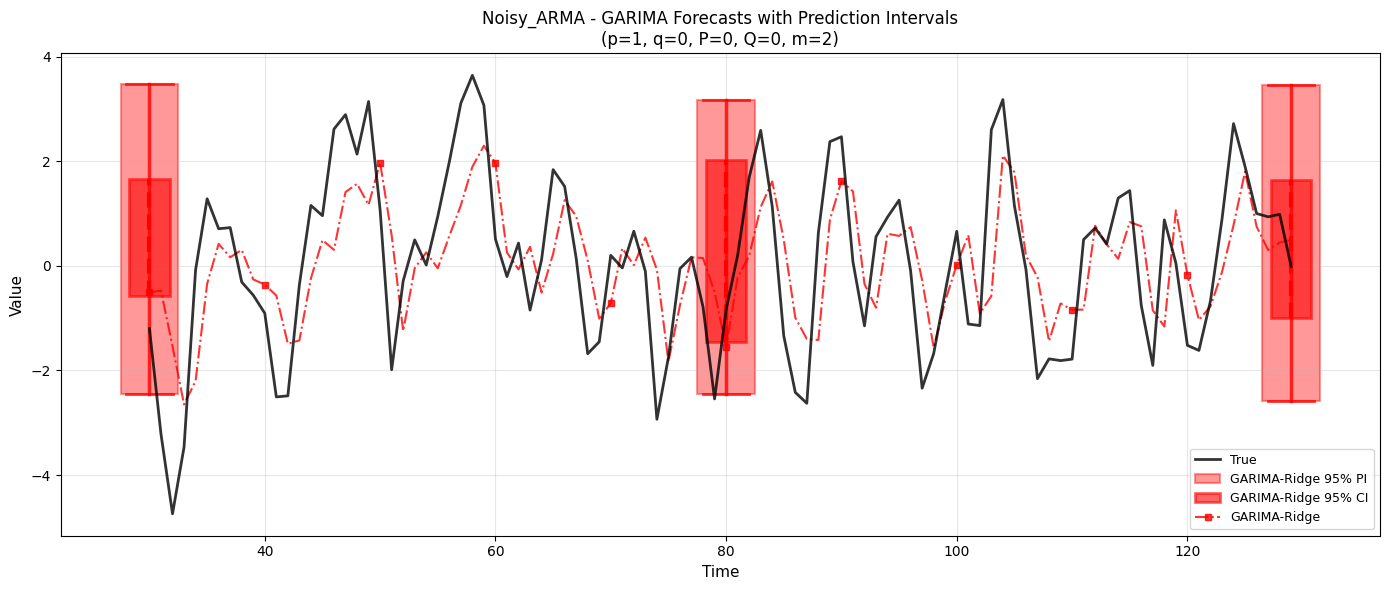


Noisy_ARMA (p=1, q=0, P=0, Q=0):
  GARIMA-OLS      - MAE: 1.2133, RMSE: 1.7781, Time: 0.20s
  GARIMA-Ridge    - MAE: 1.0516, RMSE: 1.2777, Time: 0.26s
  BIC values:
    GARIMA-OLS      - BIC: 1.3006
    GARIMA-OLS      - BIC: 1.2489
    GARIMA-OLS      - BIC: 1.3183
    GARIMA-OLS      - BIC: 1.5823
    GARIMA-OLS      - BIC: 1.5332
    GARIMA-OLS      - BIC: 1.5720
    GARIMA-OLS      - BIC: 1.5574
    GARIMA-OLS      - BIC: 1.5109
    GARIMA-OLS      - BIC: 1.4680
    GARIMA-OLS      - BIC: 1.4314
    GARIMA-OLS      - BIC: 1.3901
    GARIMA-OLS      - BIC: 1.3518
    GARIMA-OLS      - BIC: 1.3558
    GARIMA-OLS      - BIC: 1.3245
    GARIMA-OLS      - BIC: 1.3139
    GARIMA-OLS      - BIC: 1.3110
    GARIMA-OLS      - BIC: 1.2769
    GARIMA-OLS      - BIC: 1.2949
    GARIMA-OLS      - BIC: 1.2723
    GARIMA-OLS      - BIC: 1.2399
    GARIMA-OLS      - BIC: 1.2343
    GARIMA-OLS      - BIC: 1.2256
    GARIMA-OLS      - BIC: 1.2819
    GARIMA-OLS      - BIC: 1.2656
    GARIMA-OLS    

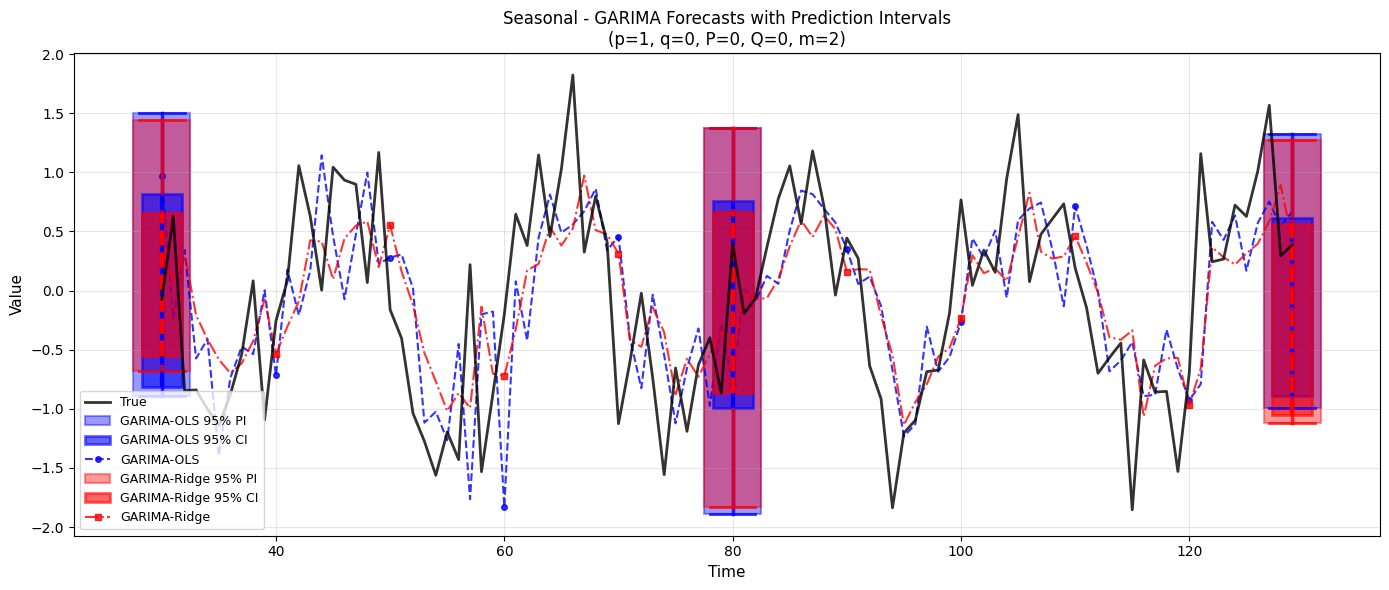


Seasonal (p=1, q=0, P=0, Q=0):
  GARIMA-OLS      - MAE: 0.5849, RMSE: 0.7290, Time: 0.19s
  GARIMA-Ridge    - MAE: 0.5335, RMSE: 0.6644, Time: 0.25s
  BIC values:
    GARIMA-OLS      - BIC: -0.2278
    GARIMA-OLS      - BIC: -0.2454
    GARIMA-OLS      - BIC: -0.2641
    GARIMA-OLS      - BIC: -0.1309
    GARIMA-OLS      - BIC: -0.1756
    GARIMA-OLS      - BIC: -0.2102
    GARIMA-OLS      - BIC: -0.2476
    GARIMA-OLS      - BIC: -0.2935
    GARIMA-OLS      - BIC: -0.3367
    GARIMA-OLS      - BIC: -0.3653
    GARIMA-OLS      - BIC: -0.2807
    GARIMA-OLS      - BIC: -0.2955
    GARIMA-OLS      - BIC: -0.3312
    GARIMA-OLS      - BIC: -0.3055
    GARIMA-OLS      - BIC: -0.3427
    GARIMA-OLS      - BIC: -0.3655
    GARIMA-OLS      - BIC: -0.3409
    GARIMA-OLS      - BIC: -0.3681
    GARIMA-OLS      - BIC: -0.3951
    GARIMA-OLS      - BIC: -0.4110
    GARIMA-OLS      - BIC: -0.3825
    GARIMA-OLS      - BIC: -0.3770
    GARIMA-OLS      - BIC: -0.3940
    GARIMA-OLS      - BIC: -0.3

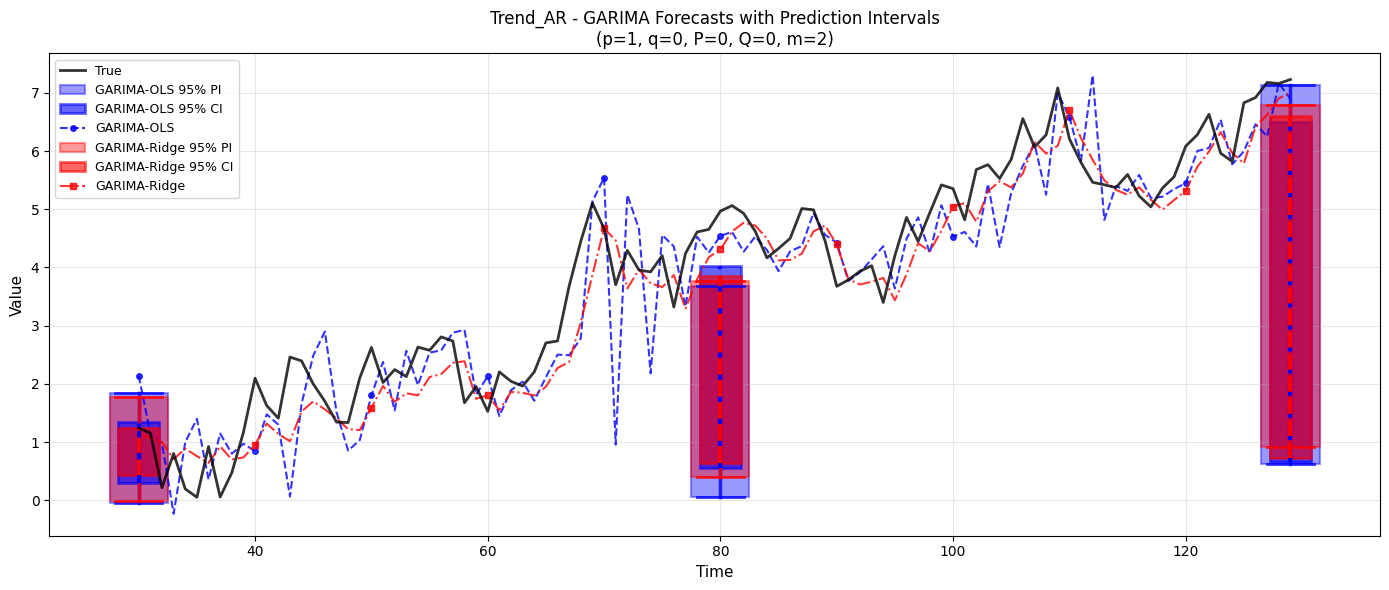


Trend_AR (p=1, q=0, P=0, Q=0):
  GARIMA-OLS      - MAE: 0.5804, RMSE: 0.7705, Time: 0.19s
  GARIMA-Ridge    - MAE: 0.4797, RMSE: 0.5863, Time: 0.25s
  BIC values:
    GARIMA-OLS      - BIC: -0.7888
    GARIMA-OLS      - BIC: -0.8454
    GARIMA-OLS      - BIC: -0.9014
    GARIMA-OLS      - BIC: -0.8094
    GARIMA-OLS      - BIC: -0.8482
    GARIMA-OLS      - BIC: -0.8146
    GARIMA-OLS      - BIC: -0.8295
    GARIMA-OLS      - BIC: -0.8284
    GARIMA-OLS      - BIC: -0.7738
    GARIMA-OLS      - BIC: -0.8170
    GARIMA-OLS      - BIC: -0.8301
    GARIMA-OLS      - BIC: -0.7132
    GARIMA-OLS      - BIC: -0.7511
    GARIMA-OLS      - BIC: -0.7869
    GARIMA-OLS      - BIC: -0.6486
    GARIMA-OLS      - BIC: -0.6750
    GARIMA-OLS      - BIC: -0.7089
    GARIMA-OLS      - BIC: -0.7431
    GARIMA-OLS      - BIC: -0.7754
    GARIMA-OLS      - BIC: -0.8053
    GARIMA-OLS      - BIC: -0.7602
    GARIMA-OLS      - BIC: -0.7419
    GARIMA-OLS      - BIC: -0.7627
    GARIMA-OLS      - BIC: -0.7

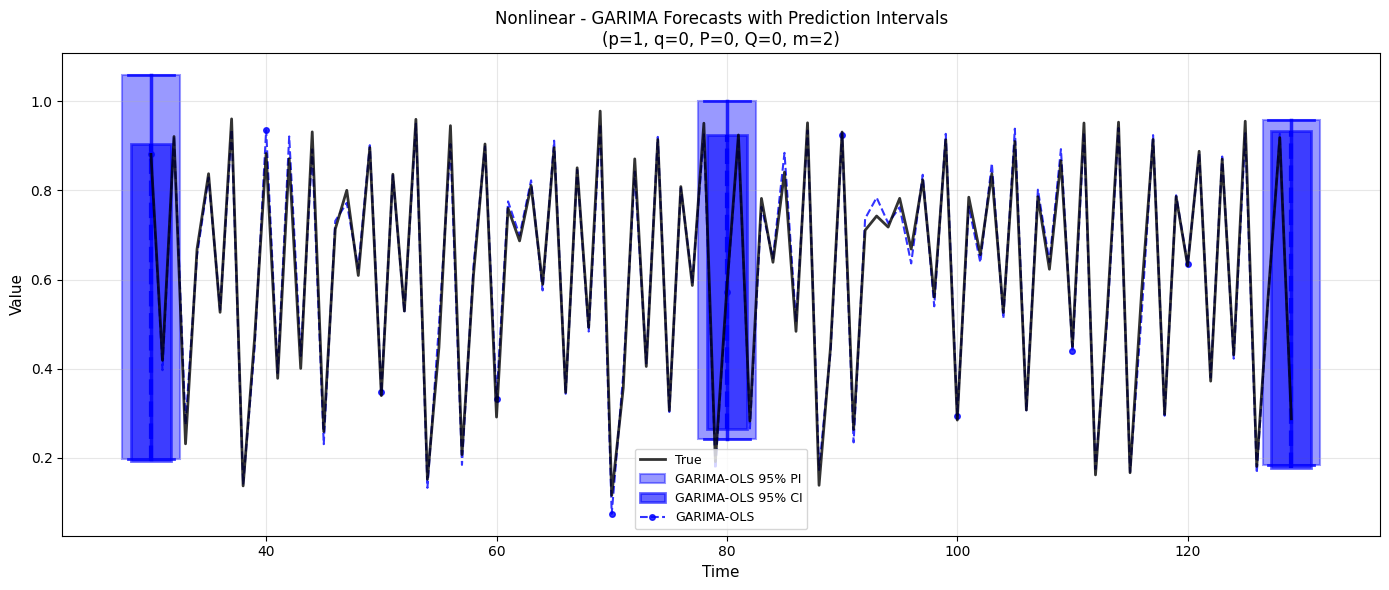


Nonlinear (p=1, q=0, P=0, Q=0):
  GARIMA-OLS      - MAE: 0.0172, RMSE: 0.0215, Time: 0.20s
  GARIMA-Ridge    - MAE: 0.1831, RMSE: 0.2129, Time: 0.26s
  BIC values:
    GARIMA-OLS      - BIC: -7.1628
    GARIMA-OLS      - BIC: -7.1987
    GARIMA-OLS      - BIC: -7.2191
    GARIMA-OLS      - BIC: -7.2716
    GARIMA-OLS      - BIC: -7.1012
    GARIMA-OLS      - BIC: -7.1499
    GARIMA-OLS      - BIC: -7.1960
    GARIMA-OLS      - BIC: -7.2364
    GARIMA-OLS      - BIC: -7.2540
    GARIMA-OLS      - BIC: -7.2966
    GARIMA-OLS      - BIC: -7.3252
    GARIMA-OLS      - BIC: -7.1224
    GARIMA-OLS      - BIC: -7.1452
    GARIMA-OLS      - BIC: -7.1773
    GARIMA-OLS      - BIC: -7.1693
    GARIMA-OLS      - BIC: -7.1456
    GARIMA-OLS      - BIC: -7.1571
    GARIMA-OLS      - BIC: -7.1853
    GARIMA-OLS      - BIC: -7.1896
    GARIMA-OLS      - BIC: -7.2219
    GARIMA-OLS      - BIC: -7.2512
    GARIMA-OLS      - BIC: -7.2712
    GARIMA-OLS      - BIC: -7.3000
    GARIMA-OLS      - BIC: -7.

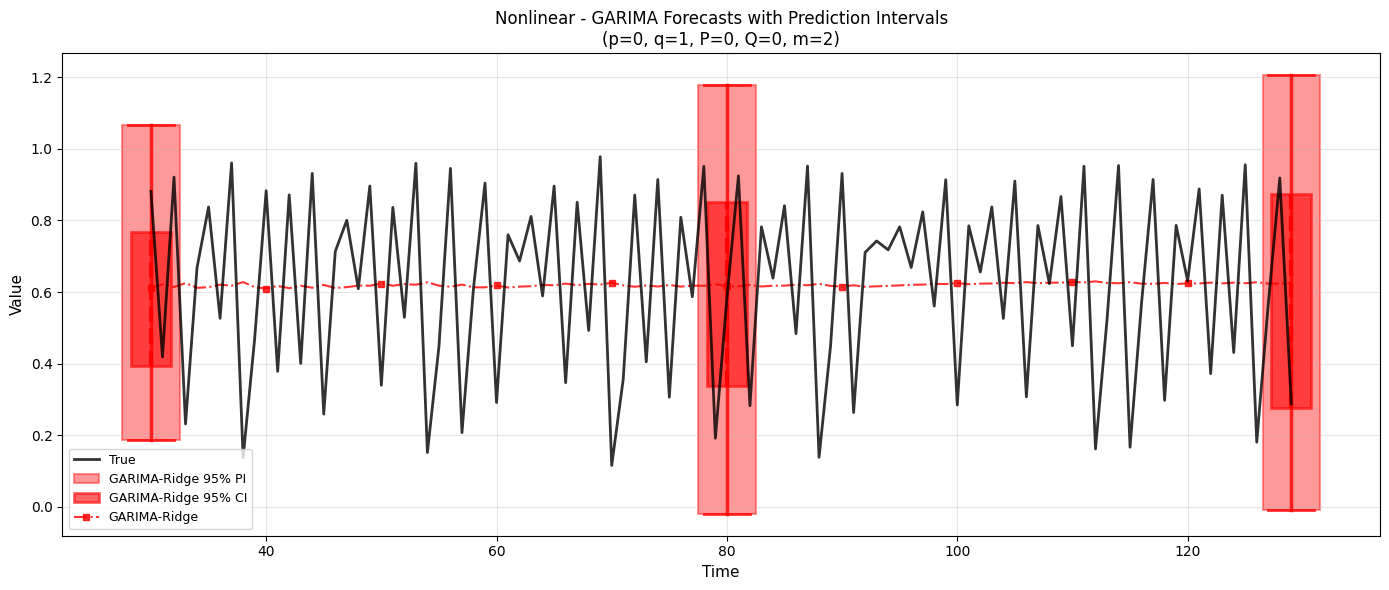


Nonlinear (p=0, q=1, P=0, Q=0):
  GARIMA-OLS      - MAE: 0.2326, RMSE: 0.2645, Time: 0.17s
  GARIMA-Ridge    - MAE: 0.2326, RMSE: 0.2645, Time: 0.23s
  BIC values:
    GARIMA-OLS      - BIC: -6.7018
    GARIMA-OLS      - BIC: -6.7501
    GARIMA-OLS      - BIC: -6.7820
    GARIMA-OLS      - BIC: -6.8441
    GARIMA-OLS      - BIC: -6.6829
    GARIMA-OLS      - BIC: -6.7405
    GARIMA-OLS      - BIC: -6.7948
    GARIMA-OLS      - BIC: -6.8443
    GARIMA-OLS      - BIC: -6.8685
    GARIMA-OLS      - BIC: -6.9189
    GARIMA-OLS      - BIC: -6.9540
    GARIMA-OLS      - BIC: -6.7600
    GARIMA-OLS      - BIC: -6.7882
    GARIMA-OLS      - BIC: -6.8267
    GARIMA-OLS      - BIC: -6.8227
    GARIMA-OLS      - BIC: -6.8045
    GARIMA-OLS      - BIC: -6.8211
    GARIMA-OLS      - BIC: -6.8543
    GARIMA-OLS      - BIC: -6.8644
    GARIMA-OLS      - BIC: -6.9017
    GARIMA-OLS      - BIC: -6.9360
    GARIMA-OLS      - BIC: -6.9604
    GARIMA-OLS      - BIC: -6.9936
    GARIMA-OLS      - BIC: -7.

In [6]:
import os

# Create folder for plots if it doesn't exist
plot_dir = "synthetic_comparison_plots"
os.makedirs(plot_dir, exist_ok=True)

# Plot comparison with prediction intervals (only for a few selected parameter combinations)
# Select best parameter combination per dataset using BIC
selected_combos = {}
if len(bic_results) > 0:
    bic_df = pd.DataFrame(bic_results)
    for name in datasets.keys():
        dataset_bic = bic_df[bic_df['Dataset'] == name]
        if not dataset_bic.empty:
            # Find best BIC per algorithm
            best_bic = dataset_bic.loc[dataset_bic.groupby('Alg')['BIC'].idxmin()]
            for _, row in best_bic.iterrows():
                combo = (name, int(row['p']), int(row['q']), int(row['P']), int(row['Q']))
                if combo not in selected_combos:
                    selected_combos[combo] = []
                selected_combos[combo].append(row['Alg'])
else:
    # Fallback: use first few combinations
    for name in datasets.keys():
        selected_combos[(name, 0, 0, 0, 0)] = ['GARIMA-OLS', 'GARIMA-Ridge']
        selected_combos[(name, 1, 1, 0, 0)] = ['GARIMA-OLS', 'GARIMA-Ridge']

# Plot selected combinations with prediction intervals
for (name, p, q, P, Q), alg_list in selected_combos.items():
    series = datasets[name]
    y_true = series[window:window+horizon]
    
    # Debug: Check if PIs exist and print their values
    print(f"\nDebug: Plotting {name} (p={p}, q={q}, P={P}, Q={Q})")
    for alg_name in alg_list:
        key = (name, p, q, P, Q, alg_name)
        if key in first_run_pis and len(first_run_pis[key]) > 0:
            print(f"  {alg_name}: Found {len(first_run_pis[key])} PI points")
            for t_idx, pi_data in first_run_pis[key].items():
                print(f"    t={t_idx}: PI=[{pi_data['pi'][0]:.3f}, {pi_data['pi'][1]:.3f}], "
                      f"CI=[{pi_data['ci_mean'][0]:.3f}, {pi_data['ci_mean'][1]:.3f}]")
        else:
            print(f"  {alg_name}: No PIs found")
    
    plt.figure(figsize=(14, 6))
    plt.plot(range(window, window+horizon), y_true, 'k-', linewidth=2, label='True', alpha=0.8, zorder=5)
    
    # Plot each algorithm with prediction intervals
    colors = {'GARIMA-OLS': 'blue', 'GARIMA-Ridge': 'red'}
    markers = {'GARIMA-OLS': 'o', 'GARIMA-Ridge': 's'}
    linestyles = {'GARIMA-OLS': '--', 'GARIMA-Ridge': '-.'}
    
    for alg_name in alg_list:
        key = (name, p, q, P, Q, alg_name)
        if key in first_run_preds:
            preds = first_run_preds[key]
            
            # Plot prediction intervals if available (for selected points)
            if key in first_run_pis:
                pi_dict = first_run_pis[key]
                pi_plotted = False
                ci_plotted = False
                
                # Collect all PI/CI data for plotting
                pi_lower = []
                pi_upper = []
                ci_lower = []
                ci_upper = []
                pi_times = []
                
                for t_idx in sorted(pi_dict.keys()):
                    pi_data = pi_dict[t_idx]
                    pi_times.append(t_idx)
                    pi_lower.append(pi_data['pi'][0])
                    pi_upper.append(pi_data['pi'][1])
                    ci_lower.append(pi_data['ci_mean'][0])
                    ci_upper.append(pi_data['ci_mean'][1])
                
                if len(pi_times) > 0:
                    # Plot PI using errorbar style for better visibility
                    bar_width = max(3, horizon // 20)  # Width of the interval bars
                    
                    # Plot PI as shaded rectangles
                    for i, t_idx in enumerate(pi_times):
                        x_left = t_idx - bar_width/2
                        x_right = t_idx + bar_width/2
                        if not pi_plotted:
                            # Draw rectangle for PI
                            rect = plt.Rectangle((x_left, pi_lower[i]), 
                                                x_right - x_left, pi_upper[i] - pi_lower[i],
                                                alpha=0.4, facecolor=colors[alg_name], 
                                                edgecolor=colors[alg_name], linewidth=1.5,
                                                label=f'{alg_name} 95% PI', zorder=1)
                            plt.gca().add_patch(rect)
                            pi_plotted = True
                        else:
                            rect = plt.Rectangle((x_left, pi_lower[i]), 
                                                x_right - x_left, pi_upper[i] - pi_lower[i],
                                                alpha=0.4, facecolor=colors[alg_name], 
                                                edgecolor=colors[alg_name], linewidth=1.5, zorder=1)
                            plt.gca().add_patch(rect)
                    
                    # Plot CI as narrower shaded rectangles
                    ci_width = bar_width * 0.7
                    for i, t_idx in enumerate(pi_times):
                        x_left = t_idx - ci_width/2
                        x_right = t_idx + ci_width/2
                        if not ci_plotted:
                            rect = plt.Rectangle((x_left, ci_lower[i]), 
                                                x_right - x_left, ci_upper[i] - ci_lower[i],
                                                alpha=0.6, facecolor=colors[alg_name], 
                                                edgecolor=colors[alg_name], linewidth=2,
                                                label=f'{alg_name} 95% CI', zorder=2)
                            plt.gca().add_patch(rect)
                            ci_plotted = True
                        else:
                            rect = plt.Rectangle((x_left, ci_lower[i]), 
                                                x_right - x_left, ci_upper[i] - ci_lower[i],
                                                alpha=0.6, facecolor=colors[alg_name], 
                                                edgecolor=colors[alg_name], linewidth=2, zorder=2)
                            plt.gca().add_patch(rect)
                    
                    # Also plot vertical error bars for extra clarity
                    for i, t_idx in enumerate(pi_times):
                        # PI error bar
                        plt.plot([t_idx, t_idx], [pi_lower[i], pi_upper[i]], 
                                color=colors[alg_name], linewidth=2.5, alpha=0.8, zorder=3, linestyle='-')
                        # CI error bar (dashed)
                        plt.plot([t_idx, t_idx], [ci_lower[i], ci_upper[i]], 
                                color=colors[alg_name], linewidth=3, alpha=1.0, zorder=4, linestyle='--')
                        # Horizontal caps for PI
                        cap_len = bar_width * 0.4
                        plt.plot([t_idx - cap_len, t_idx + cap_len], [pi_lower[i], pi_lower[i]], 
                                color=colors[alg_name], linewidth=2, alpha=0.8, zorder=3)
                        plt.plot([t_idx - cap_len, t_idx + cap_len], [pi_upper[i], pi_upper[i]], 
                                color=colors[alg_name], linewidth=2, alpha=0.8, zorder=3)
            
            plt.plot(range(window, window+horizon), preds, 
                    color=colors[alg_name], 
                    linestyle=linestyles[alg_name],
                    marker=markers[alg_name],
                    markevery=max(1, horizon//10),
                    label=alg_name,
                    alpha=0.8,
                    linewidth=1.5,
                    markersize=4)
    
    plt.title(f"{name} - GARIMA Forecasts with Prediction Intervals\n(p={p}, q={q}, P={P}, Q={Q}, m={m_seasonal})", fontsize=12)
    plt.xlabel("Time", fontsize=11)
    plt.ylabel("Value", fontsize=11)
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    plot_filename = f"{plot_dir}/{name}_p{p}_q{q}_P{P}_Q{Q}_m{m_seasonal}_with_PI.png"
    plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
    print(f"Saved: {plot_filename}")
    
    plt.show()
    
    # Print error metrics for this dataset/order combo
    print(f"\n{name} (p={p}, q={q}, P={P}, Q={Q}):")
    subset = agg[(agg['Dataset'] == name) & 
                 (agg['p'] == p) & 
                 (agg['q'] == q) & 
                 (agg['P'] == P) & 
                 (agg['Q'] == Q)]
    if not subset.empty:
        for _, row in subset.iterrows():
            print(f"  {row['Alg']:15s} - MAE: {row['MAE']:.4f}, RMSE: {row['RMSE']:.4f}, Time: {row['combo_sec']:.2f}s")
    
    # Print BIC if available
    if len(bic_results) > 0:
        bic_subset = bic_df[(bic_df['Dataset'] == name) & 
                           (bic_df['p'] == p) & 
                           (bic_df['q'] == q) & 
                           (bic_df['P'] == P) & 
                           (bic_df['Q'] == Q)]
        if not bic_subset.empty:
            print("  BIC values:")
            for _, row in bic_subset.iterrows():
                print(f"    {row['Alg']:15s} - BIC: {row['BIC']:.4f}")
    print()

SUMMARY: GARIMA Algorithm Comparison

Overall Performance (averaged across all datasets):
         Alg      MAE     RMSE  combo_sec
GARIMA-Ridge 0.679035 0.821791   0.393678
  GARIMA-OLS 0.717923 0.934007   0.310421

BIC MODEL SELECTION RESULTS

Best Model per Dataset (by BIC):
----------------------------------------------------------------------

Noisy_ARMA:
  Overall Best: GARIMA-OLS (p=1, q=0, P=1, Q=0) - BIC: 0.8424
  Best per Algorithm:
    GARIMA-OLS      (p=1, q=0, P=1, Q=0) - BIC: 0.8424 ✓
    GARIMA-Ridge    (p=1, q=0, P=0, Q=0) - BIC: 0.8589

Seasonal:
  Overall Best: GARIMA-OLS (p=1, q=0, P=0, Q=0) - BIC: -0.6354
  Best per Algorithm:
    GARIMA-OLS      (p=1, q=0, P=0, Q=0) - BIC: -0.6354 ✓
    GARIMA-Ridge    (p=1, q=0, P=0, Q=0) - BIC: -0.5988

Trend_AR:
  Overall Best: GARIMA-OLS (p=1, q=0, P=0, Q=0) - BIC: -1.1148
  Best per Algorithm:
    GARIMA-OLS      (p=1, q=0, P=0, Q=0) - BIC: -1.1148 ✓
    GARIMA-Ridge    (p=1, q=0, P=0, Q=0) - BIC: -0.9889

Nonlinear:
  Overall

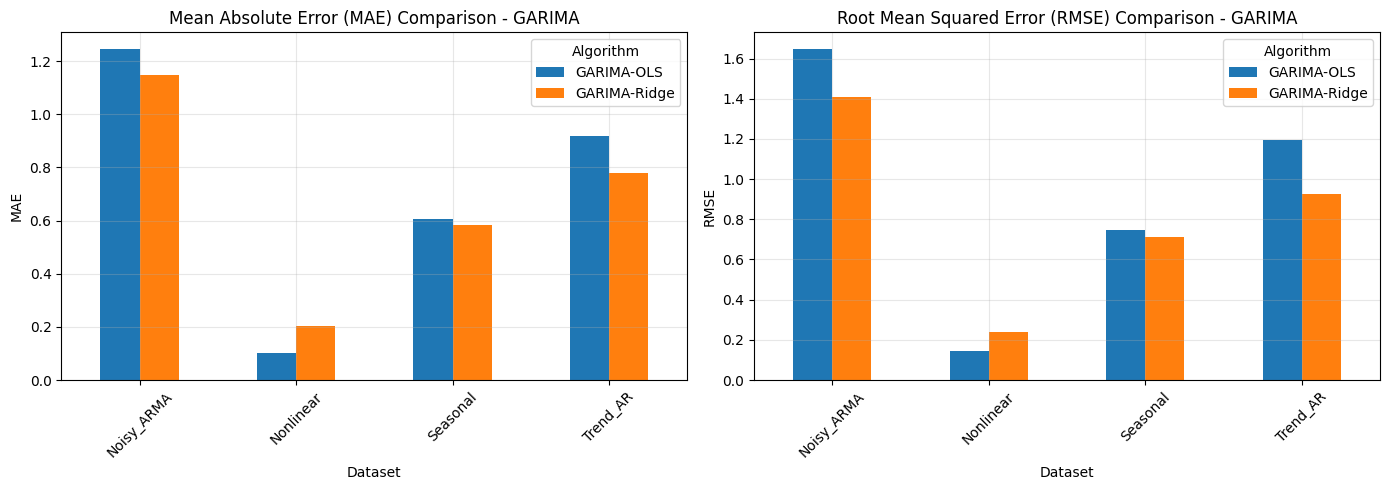


Computational Efficiency:
         Alg  mean_iter_ms  combo_sec  throughput_iters_per_sec
  GARIMA-OLS      3.104022   0.310421                352.058970
GARIMA-Ridge      3.936594   0.393678                273.678176

RESULTS TABLE: Best Models by Dataset

   Dataset    Algorithm  p  q  P  Q    MAE   RMSE Time (s)     BIC
Noisy_ARMA   GARIMA-OLS  1  0  2  0 1.0744 1.3172    0.288     NaN
Noisy_ARMA GARIMA-Ridge  1  0  1  0 1.0234 1.2312    0.311     NaN
Noisy_ARMA   GARIMA-OLS  1  0  1  0 1.2132 1.6999    0.250  0.8424
  Seasonal   GARIMA-OLS  1  0  1  0 0.5711 0.7062    0.248     NaN
  Seasonal GARIMA-Ridge  1  0  2  0 0.5210 0.6581    0.343     NaN
  Seasonal   GARIMA-OLS  1  0  0  0 0.5849 0.7290    0.195 -0.6354
  Trend_AR   GARIMA-OLS  1  0  0  0 0.5804 0.7705    0.195     NaN
  Trend_AR GARIMA-Ridge  1  0  0  0 0.4797 0.5863    0.253     NaN
 Nonlinear   GARIMA-OLS  1  0  0  0 0.0172 0.0215    0.195     NaN
 Nonlinear GARIMA-Ridge  1  0  0  0 0.1831 0.2129    0.257     NaN

Sav

In [7]:
# Summary comparison across all algorithms
print("="*70)
print("SUMMARY: GARIMA Algorithm Comparison")
print("="*70)

# Overall average across all datasets
overall = df.groupby('Alg', as_index=False)[['MAE', 'RMSE', 'combo_sec']].mean()
overall = overall.sort_values('RMSE')

print("\nOverall Performance (averaged across all datasets):")
print(overall.to_string(index=False))

# BIC Selection Results
print("\n" + "="*70)
print("BIC MODEL SELECTION RESULTS")
print("="*70)

if len(bic_results) > 0:
    bic_df = pd.DataFrame(bic_results)
    
    # Show BIC table for best models per dataset
    print("\nBest Model per Dataset (by BIC):")
    print("-" * 70)
    for name in datasets.keys():
        dataset_bic = bic_df[bic_df['Dataset'] == name]
        if not dataset_bic.empty:
            best_per_alg = dataset_bic.loc[dataset_bic.groupby('Alg')['BIC'].idxmin()]
            best_overall = dataset_bic.loc[dataset_bic['BIC'].idxmin()]
            
            print(f"\n{name}:")
            print(f"  Overall Best: {best_overall['Alg']} (p={best_overall['p']}, q={best_overall['q']}, "
                  f"P={best_overall['P']}, Q={best_overall['Q']}) - BIC: {best_overall['BIC']:.4f}")
            print(f"  Best per Algorithm:")
            for _, row in best_per_alg.iterrows():
                marker = " ✓" if row['Alg'] == best_overall['Alg'] and \
                            row['p'] == best_overall['p'] and row['q'] == best_overall['q'] and \
                            row['P'] == best_overall['P'] and row['Q'] == best_overall['Q'] else ""
                print(f"    {row['Alg']:15s} (p={row['p']}, q={row['q']}, P={row['P']}, Q={row['Q']}) "
                      f"- BIC: {row['BIC']:.4f}{marker}")
    
    # Create BIC summary table
    print("\n" + "="*70)
    print("BIC Summary Table (Top 5 per Dataset):")
    print("="*70)
    for name in datasets.keys():
        dataset_bic = bic_df[bic_df['Dataset'] == name].copy()
        if not dataset_bic.empty:
            dataset_bic = dataset_bic.sort_values('BIC').head(5)
            print(f"\n{name}:")
            print(dataset_bic[['Alg', 'p', 'q', 'P', 'Q', 'BIC']].to_string(index=False))
else:
    print("\nNo BIC results available (models may have failed to fit)")

results_dir = "syntheticresults"
os.makedirs(results_dir, exist_ok=True)

with open(f"{results_dir}/summary_comparison.txt", 'w') as f:
    f.write("Overall Performance (averaged across all datasets):\n")
    f.write(overall.to_string(index=False))
print(f"Saved summary table to: {results_dir}/summary_comparison.txt")



# Best performer per dataset
print("\n" + "="*70)
print("Best Algorithm Per Dataset (by RMSE):")
print("="*70)

for dataset in df['Dataset'].unique():
    dataset_df = df[df['Dataset'] == dataset]
    best = dataset_df.groupby('Alg', as_index=False)[['MAE', 'RMSE']].mean()
    best = best.sort_values('RMSE')
    winner = best.iloc[0]
    
    print(f"\n{dataset}:")
    print(f"  Winner: {winner['Alg']}")
    print(f"  MAE: {winner['MAE']:.4f}, RMSE: {winner['RMSE']:.4f}")
    print(f"  All algorithms:")
    for _, row in best.iterrows():
        improvement = ((best.iloc[0]['RMSE'] - row['RMSE']) / best.iloc[0]['RMSE']) * 100 if row['Alg'] != winner['Alg'] else 0
        status = "✓" if row['Alg'] == winner['Alg'] else f"  (+{-improvement:.1f}%)"
        print(f"    {row['Alg']:15s}: MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f} {status}")

# Create bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
mae_pivot = df.groupby(['Dataset', 'Alg'])['MAE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='MAE'
)
mae_pivot.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Mean Absolute Error (MAE) Comparison - GARIMA')
axes[0].set_ylabel('MAE')
axes[0].legend(title='Algorithm', loc='best')
axes[0].grid(True, alpha=0.3)

# RMSE comparison
rmse_pivot = df.groupby(['Dataset', 'Alg'])['RMSE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='RMSE'
)
rmse_pivot.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Root Mean Squared Error (RMSE) Comparison - GARIMA')
axes[1].set_ylabel('RMSE')
axes[1].legend(title='Algorithm', loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{plot_dir}/GARIMA_comparison_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# Timing comparison
print("\n" + "="*70)
print("Computational Efficiency:")
print("="*70)
timing = df.groupby('Alg', as_index=False)[['mean_iter_ms', 'combo_sec', 'throughput_iters_per_sec']].mean()
timing = timing.sort_values('combo_sec')
print(timing.to_string(index=False))

# Display a clean results table
print("\n" + "="*70)
print("RESULTS TABLE: Best Models by Dataset")
print("="*70)

# Create a summary table with best model per dataset
summary_table = []
for dataset in df['Dataset'].unique():
    dataset_df = df[df['Dataset'] == dataset]
    # Best by RMSE
    best_rmse = dataset_df.loc[dataset_df.groupby('Alg')['RMSE'].idxmin()]
    for _, row in best_rmse.iterrows():
        summary_table.append({
            'Dataset': dataset,
            'Algorithm': row['Alg'],
            'p': int(row['p']),
            'q': int(row['q']),
            'P': int(row['P']),
            'Q': int(row['Q']),
            'MAE': f"{row['MAE']:.4f}",
            'RMSE': f"{row['RMSE']:.4f}",
            'Time (s)': f"{row['combo_sec']:.3f}"
        })
    
    # Add BIC if available
    if len(bic_results) > 0:
        bic_df = pd.DataFrame(bic_results)
        dataset_bic = bic_df[bic_df['Dataset'] == dataset]
        if not dataset_bic.empty:
            best_bic = dataset_bic.loc[dataset_bic['BIC'].idxmin()]
            # Check if already in table
            exists = any(t['Dataset'] == dataset and 
                       t['Algorithm'] == best_bic['Alg'] and
                       t['p'] == int(best_bic['p']) and t['q'] == int(best_bic['q']) and
                       t['P'] == int(best_bic['P']) and t['Q'] == int(best_bic['Q'])
                       for t in summary_table)
            if not exists:
                # Find corresponding RMSE row
                matching = df[(df['Dataset'] == dataset) & 
                             (df['Alg'] == best_bic['Alg']) &
                             (df['p'] == best_bic['p']) & (df['q'] == best_bic['q']) &
                             (df['P'] == best_bic['P']) & (df['Q'] == best_bic['Q'])]
                if not matching.empty:
                    row = matching.iloc[0]
                    summary_table.append({
                        'Dataset': dataset,
                        'Algorithm': best_bic['Alg'],
                        'p': int(best_bic['p']),
                        'q': int(best_bic['q']),
                        'P': int(best_bic['P']),
                        'Q': int(best_bic['Q']),
                        'MAE': f"{row['MAE']:.4f}",
                        'RMSE': f"{row['RMSE']:.4f}",
                        'Time (s)': f"{row['combo_sec']:.3f}",
                        'BIC': f"{best_bic['BIC']:.4f}"
                    })

summary_df = pd.DataFrame(summary_table)
if 'BIC' in summary_df.columns:
    print("\n" + summary_df.to_string(index=False))
else:
    print("\n" + summary_df.to_string(index=False))
    
# Save summary table
summary_df.to_csv(f"{results_dir}/summary_results_table.csv", index=False)
print(f"\nSaved summary table to: {results_dir}/summary_results_table.csv")


Generating inference table for Trend_AR
Best model: GARIMA-OLS with order (p=1, q=0, P=0, Q=0)
BIC: -1.1148

Computing inference statistics using block bootstrap...
(This may take a moment...)

Regression-Style Summary Table

Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Variable       Coef   Std Err         t    P>|t|      [0.025    0.975] Significance
     AR(1)   5.199360 15.049136  0.345492 0.729724  -19.629444 37.953794             
     AR(2)   0.597783  3.020457  0.197911 0.843114   -1.900841  8.999203             
     AR(3)   1.972237  3.727758  0.529068 0.596758   -4.544309  9.895491             
     AR(4)  -2.191237  3.671887 -0.596760 0.550667   -5.879426  5.783164             
     AR(5)   2.211794  2.791653  0.792288 0.428193   -3.526247  7.306640             
     AR(6)  -1.380384  3.539870 -0.389953 0.696571   -8.201854  6.591897             
     AR(7)   2.079196  3.222741  0.645164 0.518821   -6.663249  7.613199             
     AR(8)  -1.122

## GARIMA Summary Table Explained

**Call:** Model specification (order, seasonal_order).

**Residuals:** Min, 1Q, Median, 3Q, Max — five-number summary of fitted residuals (observed − predicted).

**Coefficients:**
- **AR_b1, AR_b2, AR_b3:** AR basis coefficients (linear + quadratic in lags). For order (1,0,1), the default quadratic basis yields 3 AR features.
- **MA_b1, MA_b2, MA_b3:** MA basis coefficients on residual lags.
- **Estimate:** Point estimate.
- **Std. Error:** Bootstrap standard error.
- **t value:** t-statistic = Estimate / Std. Error.
- **Pr(>|t|):** Two-sided p-value for H0: coefficient = 0.
- **Significance:** `***` p<0.001, `**` p<0.01, `*` p<0.05, `.` p<0.1.

**Model fit:**
- **Residual standard error:** sqrt(RSS/df).
- **R-squared:** Fraction of variance explained.
- **F-statistic:** Overall model significance.
- **BIC:** Bayesian Information Criterion (lower = better for model selection).

One-step forecast: 0.1088
Point forecast: 0.1088
95% PI: [-3.3261, 3.0549]


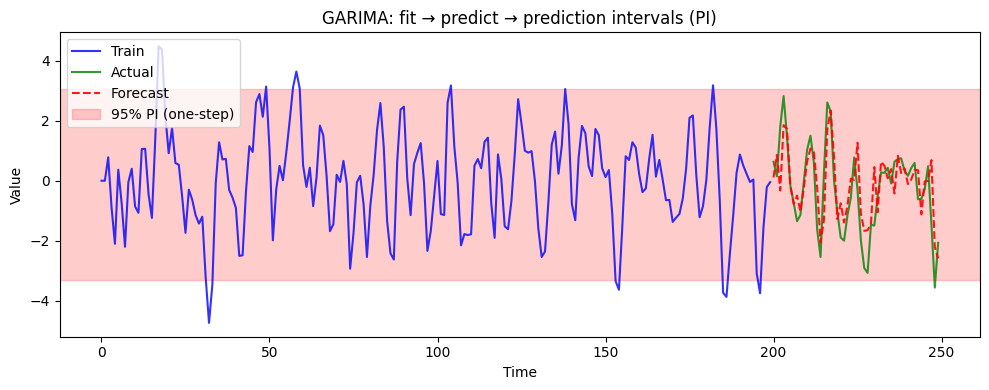

In [10]:
# 1. Prepare data: train on first 200 points, forecast next 50
y = datasets['Noisy_ARMA']  # or y_a
train = y[:200]
test = y[200:250]
n_forecast = len(test)

# 2. Create model and fit
model = GalerkinSARIMA(
    order=(2, 0, 2),           # ARIMA(p,d,q)，d=0
    seasonal_order=(0, 0, 0, 2),  # (P,D,Q,m)
    use_ridge=False            # OLS
)
model.fit(train)

# 3. One-step forecast
pred_one = model.forecast(steps=1)
print(f"One-step forecast: {pred_one:.4f}")

# 4. Rolling forecast with per-step PI and CI
# method='residual' is fast; use method='bootstrap' for more accurate intervals (slower)
roll_result = model.rolling_prediction_intervals(
    train, n_forecast, actuals=test,
    method='residual',   # or 'bootstrap' with n_bootstrap=200
    alpha=0.05
)
preds = roll_result['forecasts']
pi_lo, pi_hi = roll_result['pi_lower'], roll_result['pi_upper']
ci_lo, ci_hi = roll_result['ci_lower'], roll_result['ci_upper']

print(f"First-step forecast: {preds[0]:.4f}")
print(f"First-step 95% PI: [{pi_lo[0]:.4f}, {pi_hi[0]:.4f}]")
print(f"First-step 95% CI: [{ci_lo[0]:.4f}, {ci_hi[0]:.4f}]")

# 5. Plot: train + actual + forecast + rolling PI + rolling CI
fig, ax = plt.subplots(figsize=(10, 4))
t_train = np.arange(len(train))
t_test = np.arange(len(train), len(train) + n_forecast)

ax.plot(t_train, train, 'b-', label='Train', alpha=0.8)
ax.plot(t_test, test, 'g-', label='Actual', alpha=0.8)
ax.plot(t_test, preds, 'r--', label='Forecast', alpha=0.9)

# Rolling PI (wider band, per-step)
ax.fill_between(t_test, pi_lo, pi_hi, alpha=0.2, color='red', label='95% PI (rolling)')
# Rolling CI (narrower band, per-step)
ax.fill_between(t_test, ci_lo, ci_hi, alpha=0.3, color='blue', label='95% CI (rolling)')

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend(loc='upper left')
ax.set_title('GARIMA: fit → predict → rolling PI & CI')
plt.tight_layout()
plt.show()

In [11]:
model.summary(train)

Call:
  GalerkinSARIMA(order=(2, 0, 2), seasonal_order=(0, 0, 0, 2))

Residuals:
     Min       1Q   Median       3Q      Max
  -3.7929   -0.8849   -0.1364    0.8691    3.6163

Coefficients:
                    Estimate   Std. Error    t value     Pr(>|t|)
-----------------------------------------------------------------
AR_b1                -0.0151       0.0546    -0.2773     0.7816  
AR_b2                 0.9664       0.0777    12.4325   <2e-16 ***
AR_b3                -0.4905       0.0655    -7.4860     0.0000 ***
AR_b4                 0.0167       0.0260     0.6409     0.5216  
AR_b5                -0.0029       0.0247    -0.1185     0.9056  
MA_b1                 0.0355       0.0320     1.1088     0.2675  
MA_b2                 0.1346       0.0384     3.5014     0.0005 ***
MA_b3                -0.2043       0.0484    -4.2192     0.0000 ***
MA_b4                -0.0670       0.0456    -1.4681     0.1421  
MA_b5                 0.0130       0.0324     0.4004     0.6889  
-----------

In [12]:
roll_result = model.rolling_prediction_intervals(
    train, n_forecast, actuals=test,
    method='residual',   # fast; use 'bootstrap' for more accurate intervals
    alpha=0.05
)

# Plot
ax.fill_between(t_test, roll_result['pi_lower'], roll_result['pi_upper'], 
                alpha=0.2, color='red', label='95% PI (rolling)')
ax.fill_between(t_test, roll_result['ci_lower'], roll_result['ci_upper'], 
                alpha=0.3, color='blue', label='95% CI (rolling)')

AttributeError: 'GalerkinSARIMA' object has no attribute 'rolling_prediction_intervals'